<a href="https://colab.research.google.com/github/Jo-ohnny/CI345_ML/blob/main/Lab12_Linear_Regression_CA_House_finished_by_Jean_Copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Lab12_Linear_Regression_CA_House

## Date: 5/27/2026

### Name: Jean eudes Oussou


#Step 1 : Loading and Analyze Data

In [5]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Path to your CSV in Drive
CA_house_file = '/content/drive/MyDrive/CI345_ML/data/CA_house_value.csv'
CA_house_dataset = pd.read_csv(CA_house_file)
print(CA_house_dataset.shape)
CA_house_dataset.head(3)

(20640, 10)


,longitude,latitude,age,total_rooms,bedrooms,population,households,income,ocean,house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100


In [13]:
CA_house_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   longitude    20640 non-null  float64
 1   latitude     20640 non-null  float64
 2   age          20640 non-null  int64  
 3   total_rooms  20640 non-null  int64  
 4   bedrooms     20433 non-null  float64
 5   population   20640 non-null  int64  
 6   households   20640 non-null  int64  
 7   income       20640 non-null  float64
 8   ocean        20640 non-null  object 
 9   house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


###The California Housing dataset is a well-known dataset in machine learning, often used for regression tasks such as predicting house prices. It is derived from the 1990 U.S. Census and contains aggregated data for each census block group in California

#Step 2 : Basic Data Analysis

In [9]:
df = CA_house_dataset.copy()
df.head(2)
print(df.shape)
print('---')
print(df.columns)

(20640, 10)
---
Index(['longitude', 'latitude', 'age', 'total_rooms', 'bedrooms', 'population',
       'households', 'income', 'ocean', 'house_value'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   longitude    20640 non-null  float64
 1   latitude     20640 non-null  float64
 2   age          20640 non-null  int64  
 3   total_rooms  20640 non-null  int64  
 4   bedrooms     20433 non-null  float64
 5   population   20640 non-null  int64  
 6   households   20640 non-null  int64  
 7   income       20640 non-null  float64
 8   ocean        20640 non-null  object 
 9   house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [11]:
print(df.dtypes)
print(df.columns  )

longitude      float64
latitude       float64
age              int64
total_rooms      int64
bedrooms       float64
population       int64
households       int64
income         float64
ocean           object
house_value      int64
dtype: object
Index(['longitude', 'latitude', 'age', 'total_rooms', 'bedrooms', 'population',
       'households', 'income', 'ocean', 'house_value'],
      dtype='object')


In [12]:
df.isnull().sum()

,0
longitude,0
latitude,0
age,0
total_rooms,0
bedrooms,207
population,0
households,0
income,0
ocean,0
house_value,0


In [28]:
print(df.age.describe())
print('------------------------')
print(df['house_value'].describe())
print(df[ ['age','house_value']].describe())

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: age, dtype: float64
------------------------
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: house_value, dtype: float64
                age    house_value
count  20640.000000   20640.000000
mean      28.639486  206855.816909
std       12.585558  115395.615874
min        1.000000   14999.000000
25%       18.000000  119600.000000
50%       29.000000  179700.000000
75%       37.000000  264725.000000
max       52.000000  500001.000000


In [16]:
print(df.age.min())
print(df.age.max())
print(df.age.mean())
print(df.age.std())
df.head(3)

1
52
28.639486434108527
12.585557612111637


,longitude,latitude,age,total_rooms,bedrooms,population,households,income,ocean,house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100


In [17]:
df.ocean.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [19]:
df.ocean.value_counts()

,count
ocean,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


# Step 3 : Data Visualization

<Axes: title={'center': 'Ocean'}, ylabel='count'>

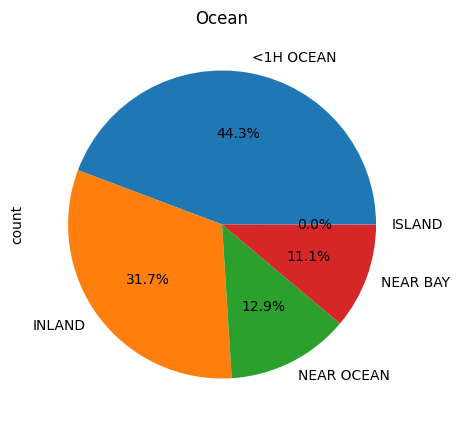

In [23]:
res = df['ocean'].value_counts()

res.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Ocean',
    figsize = (5, 5)
   )

In [22]:
df = CA_house_dataset.copy()
df.head(2)

,longitude,latitude,age,total_rooms,bedrooms,population,households,income,ocean,house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500


ocean
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


<Axes: title={'center': 'Numbers of Houses'}, xlabel='ocean'>

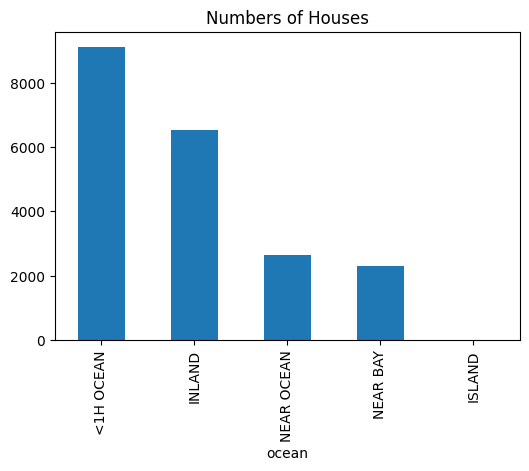

In [25]:
res = df.ocean.value_counts()
print(res)
res.plot(kind='bar',title='Numbers of Houses', figsize=(6, 4) )

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: house_value, dtype: float64


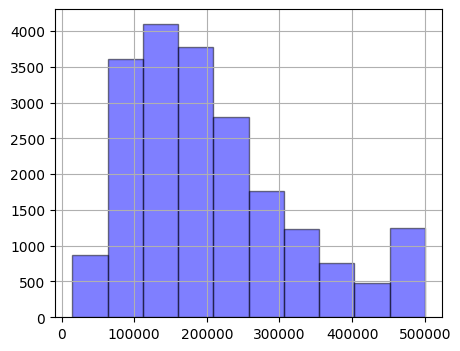

In [27]:
res = df["house_value"]
print(res.describe())

#res.plot(kind="hist", bins=5)
res.hist( bins=10, color='blue',alpha=0.5, edgecolor = "black",figsize=(5, 4));

19643


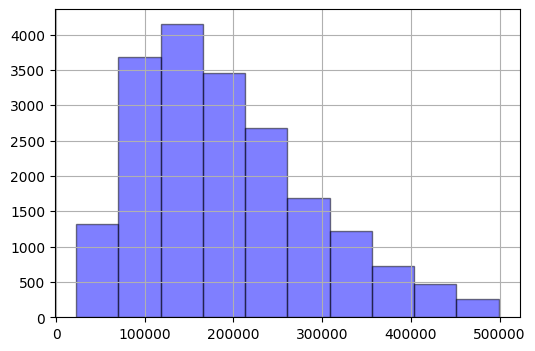

In [35]:
res = df[(df.house_value >20000) & (df.house_value < 500000) ]['house_value']
print(len(res))

#res.plot(kind="hist", bins=5)
res.hist( bins=10, color='blue',alpha=0.5, edgecolor = "black",figsize=(6, 4));

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: age, dtype: float64


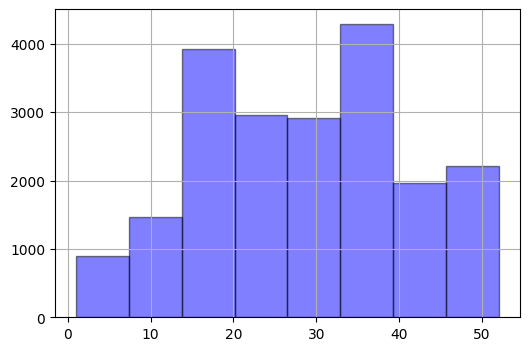

In [36]:
res = df['age']
print(res.describe())

#res.plot(kind="hist", bins=5)
res.hist( bins=8, color='blue',alpha=0.5, edgecolor = "black",figsize=(6, 4));

In [37]:
df.columns

Index(['longitude', 'latitude', 'age', 'total_rooms', 'bedrooms', 'population',
       'households', 'income', 'ocean', 'house_value'],
      dtype='object')

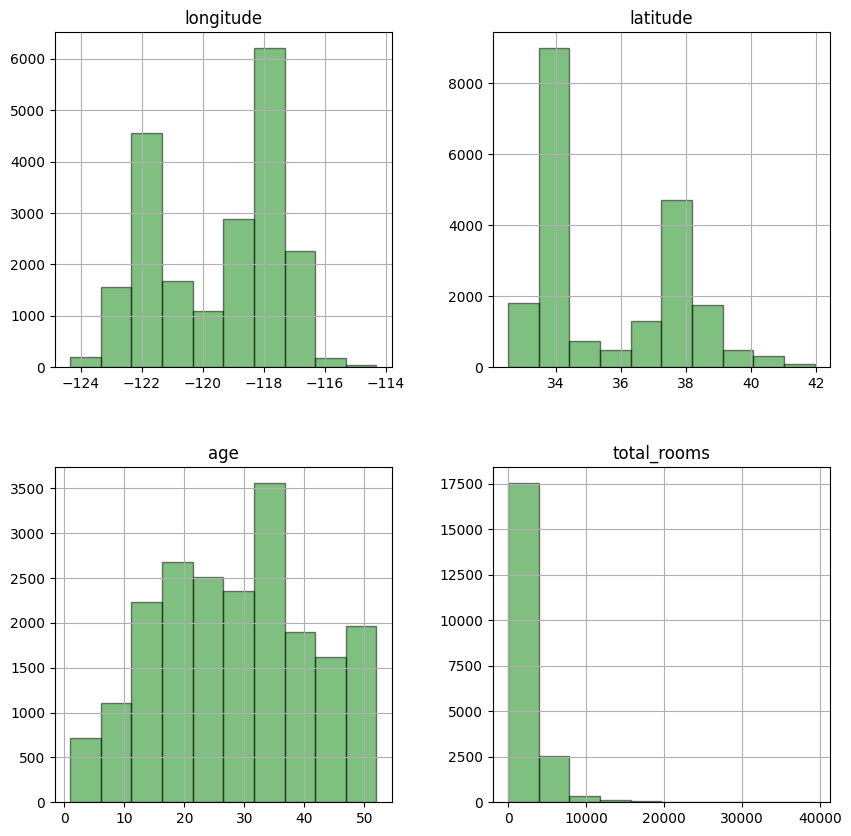

In [40]:

columns= ['longitude', 'latitude', 'age', 'total_rooms']
res = df[columns ]
res.hist(color='green',alpha=0.5, edgecolor = "black",figsize=(10, 10));


In [41]:
df.describe()

,longitude,latitude,age,total_rooms,bedrooms,population,households,income,house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


ocean
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


<Axes: title={'center': 'Numbers of Houses'}, xlabel='ocean'>

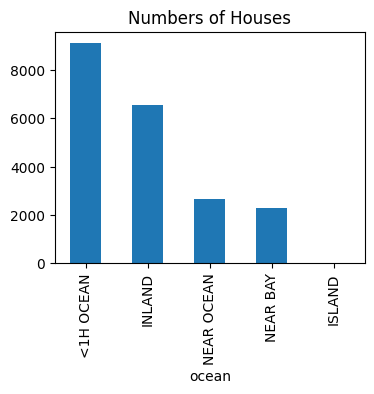

In [43]:
res = df['ocean'].value_counts()
print(res)
res.plot( kind='bar',  title='Numbers of Houses', figsize=(4, 3) )

# Step 4 : Data Processomg
# Convert categorical features to numerical feature


In [44]:
df = CA_house_dataset.copy()
df.head(2)

,longitude,latitude,age,total_rooms,bedrooms,population,households,income,ocean,house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500


In [47]:

df.ocean.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [48]:
# Define the order
print(df.head(2))
hist_map = {'NEAR BAY':2, '<1H OCEAN':2, 'INLAND':1, 'NEAR OCEAN':4, 'ISLAND':5}
# Apply mapping and get new columns
df['ocean'] = df['ocean'].map(hist_map)
df.head(2)

   longitude  latitude  age  total_rooms  bedrooms  population  households  \
0    -122.23     37.88   41          880     129.0         322         126   
1    -122.22     37.86   21         7099    1106.0        2401        1138   

   income     ocean  house_value  
0  8.3252  NEAR BAY       452600  
1  8.3014  NEAR BAY       358500  


,longitude,latitude,age,total_rooms,bedrooms,population,households,income,ocean,house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,2,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,2,358500


#Step 5: Seperate Data and Target

In [49]:
print(df.columns)
df.head(2)

Index(['longitude', 'latitude', 'age', 'total_rooms', 'bedrooms', 'population',
       'households', 'income', 'ocean', 'house_value'],
      dtype='object')


,longitude,latitude,age,total_rooms,bedrooms,population,households,income,ocean,house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,2,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,2,358500


In [50]:
# Current process data has not category
print(df.columns)
cols_used = ['longitude', 'latitude', 'age', 'total_rooms', 'bedrooms', 'population',
       'households', 'income', 'ocean']
# Seperate data part
data = df[cols_used]
# Get target
target = df['house_value']

print(data.shape)
print(target.shape)
print(target.head(2)  )
data.head(3)

Index(['longitude', 'latitude', 'age', 'total_rooms', 'bedrooms', 'population',
       'households', 'income', 'ocean', 'house_value'],
      dtype='object')
(20640, 9)
(20640,)
0    452600
1    358500
Name: house_value, dtype: int64


,longitude,latitude,age,total_rooms,bedrooms,population,households,income,ocean
0,-122.23,37.88,41,880,129.0,322,126,8.3252,2
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,2
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,2


#Step 6: Apply Linear Regression

In [ ]:
# Step : Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (data, target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 25
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(80000, 13)
(20000, 13)
(80000,)
(20000,)
KNeighborsClassifier(n_neighbors=25, weights='distance')
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     18309
           1       0.95      0.48      0.64      1691

    accuracy                           0.95     20000
   macro avg       0.95      0.74      0.81     20000
weighted avg       0.95      0.95      0.95     20000

------ Confusion Matrix
[[18267    42]
 [  880   811]]


In [ ]:
# Step 4: Create a decision tree
from sklearn import tree
dt_classifier = tree.DecisionTreeClassifier()

#Training the decision classifier
dt_classifier.fit (X = data_train, y = target_train)
print(dt_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation, Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     18309
           1       0.75      0.59      0.66      1691

    accuracy                           0.95     20000
   macro avg       0.86      0.79      0.82     20000
weighted avg       0.95      0.95      0.95     20000

------ Confusion Matrix
[[17982   327]
 [  689  1002]]


In [ ]:
# Step 4: Create a SVM
from sklearn import svm
svm_classifier = svm.SVC()

#Training the decision classifier
svm_classifier.fit (X = data_train, y = target_train)
print(svm_classifier)

# Step 5: Testing
predicted = svm_classifier.predict(X= data_test)

# Step 6: Evaluation, Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

SVC()
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     18309
           1       1.00      0.39      0.56      1691

    accuracy                           0.95     20000
   macro avg       0.97      0.70      0.77     20000
weighted avg       0.95      0.95      0.94     20000

------ Confusion Matrix
[[18309     0]
 [ 1028   663]]
